## Loan Approval Prediction - End-to-End Classification Project

A complete binary classification workflow: EDA, cleaning, outlier detection, encoding, scaling, model training (5 algorithms), evaluation, comparison, hyperparameter tuning, and saving the best model for deployment in a Streamlit app.

### 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import(
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
)

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

RANDOM_STATE = 42

### 2. Load Dataset

In [5]:
df = pd.read_csv("loan_prediction_dataset.csv")
df.head()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0
3,32,127188,364,16886,24,Unemployed,0
4,60,25655,307,26256,36,Unemployed,0


### 3. Explore the Dataset

In [6]:
df.tail()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
1995,63,87580,761,29716,48,Employed,1
1996,67,27368,695,13601,36,Employed,0
1997,69,105436,636,37018,36,Self-Employed,0
1998,24,116136,441,9061,48,Employed,0
1999,20,66403,616,9609,12,Unemployed,0


In [7]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))

Shape: (2000, 7)

Columns: ['Age', 'Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term', 'Employment_Status', 'Loan_Approved']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                2000 non-null   int64 
 1   Income             2000 non-null   int64 
 2   Credit_Score       2000 non-null   int64 
 3   Loan_Amount        2000 non-null   int64 
 4   Loan_Term          2000 non-null   int64 
 5   Employment_Status  2000 non-null   object
 6   Loan_Approved      2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB


In [9]:
df.describe()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Loan_Approved
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,43.805500,84533.585000,577.055000,25460.315000,35.47800,0.171000
std,14.929203,37771.169751,157.525951,14116.737774,16.98587,0.376603
min,18.000000,20155.000000,300.000000,1060.000000,12.00000,0.000000
25%,31.000000,50925.250000,440.000000,13444.250000,24.00000,0.000000
50%,44.000000,84073.500000,578.500000,25446.000000,36.00000,0.000000
75%,56.000000,117523.250000,715.250000,37949.250000,48.00000,0.000000
max,69.000000,149992.000000,849.000000,49994.000000,60.00000,1.000000


In [11]:
print("Missing Values per column:")
df.isna().sum()

Missing Values per column:


Age                  0
Income               0
Credit_Score         0
Loan_Amount          0
Loan_Term            0
Employment_Status    0
Loan_Approved        0
dtype: int64

In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [13]:
df['Loan_Approved'].value_counts()

Loan_Approved
0    1658
1     342
Name: count, dtype: int64

In [14]:
df['Loan_Approved'].value_counts(normalize=True)*100

Loan_Approved
0    82.9
1    17.1
Name: proportion, dtype: float64

### 4. Handle Missing Values
The dataset has no missing values, so no imputation is required. The code below is kept as a general-purpose safeguard in case the raw data changes.

In [15]:
num_cols = ["Age","Income","Credit_Score","Loan_Amount","Loan_Term"]
cat_cols = ["Employment_Status"]

for c in num_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

for c in cat_cols:
    if df[c].isna().sum() > 0:
        df[c] = df[c].fillna(df[c].mode()[0])

df.isna().sum().sum()

np.int64(0)

### 5. Remove Duplicates

In [18]:
before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]
print(f"Removed {before - after} duplicate rows.")

Removed 0 duplicate rows.


### 6. Exploratory Data Analysis (EDA)

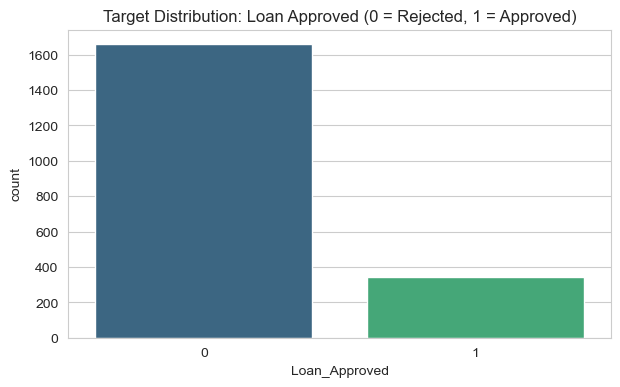

In [19]:
plt.figure()
sns.countplot(x="Loan_Approved", data=df, palette="viridis")
plt.title("Target Distribution: Loan Approved (0 = Rejected, 1 = Approved)")
plt.show()

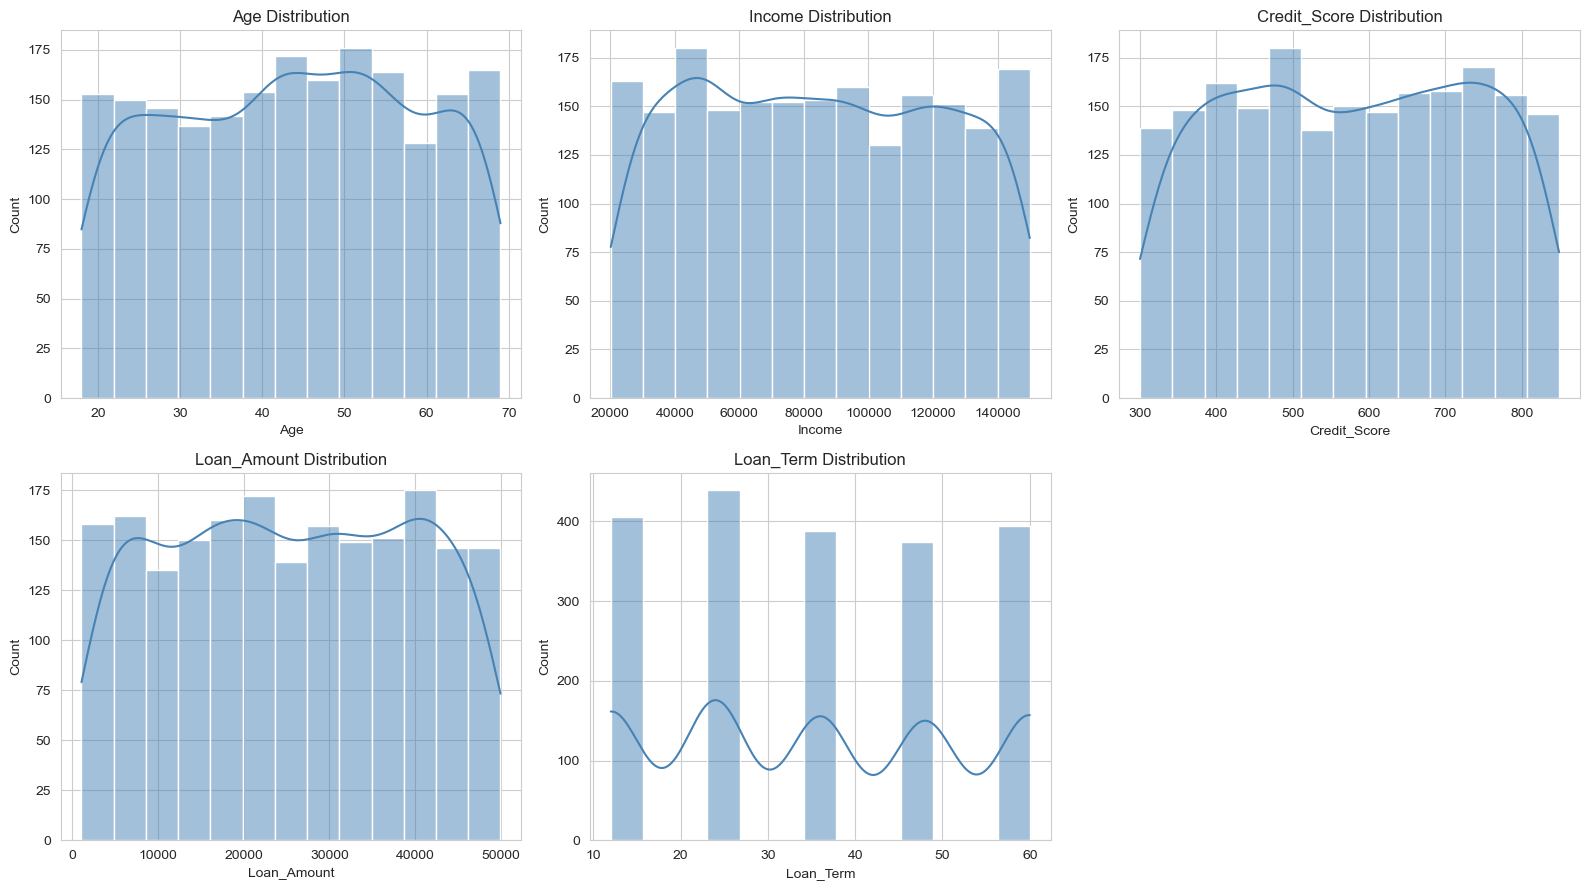

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
num_features = ["Age", "Income", "Credit_Score", "Loan_Amount","Loan_Term"]
list(zip(axes.flatten(), num_features))
for ax, col in zip(axes.flatten(), num_features):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"{col} Distribution")
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.show()

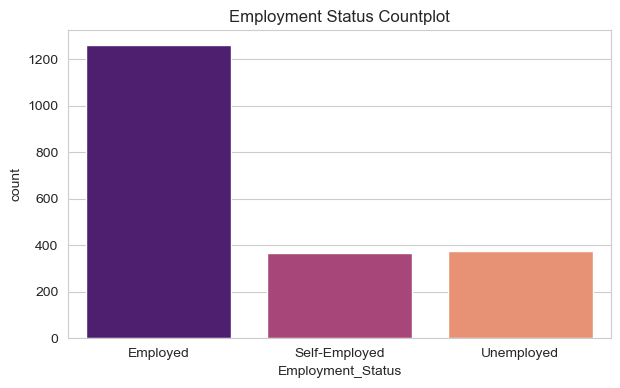

In [21]:
plt.figure()
sns.countplot(x="Employment_Status", data=df, palette="magma")
plt.title("Employment Status Countplot")
plt.show()

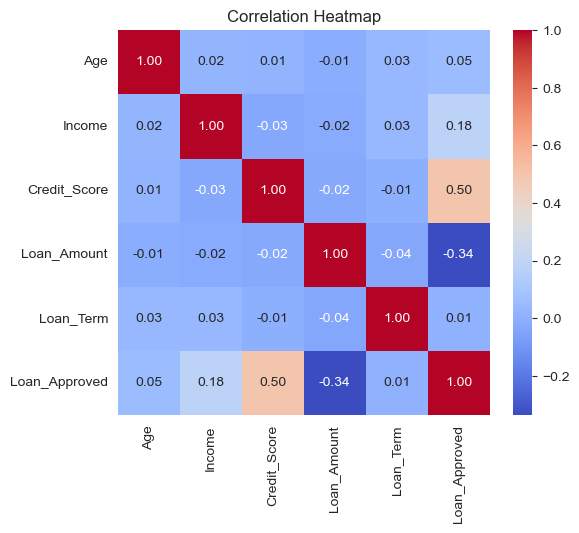

In [22]:
plt.figure(figsize=(6, 5))
corr = df[num_features + ["Loan_Approved"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

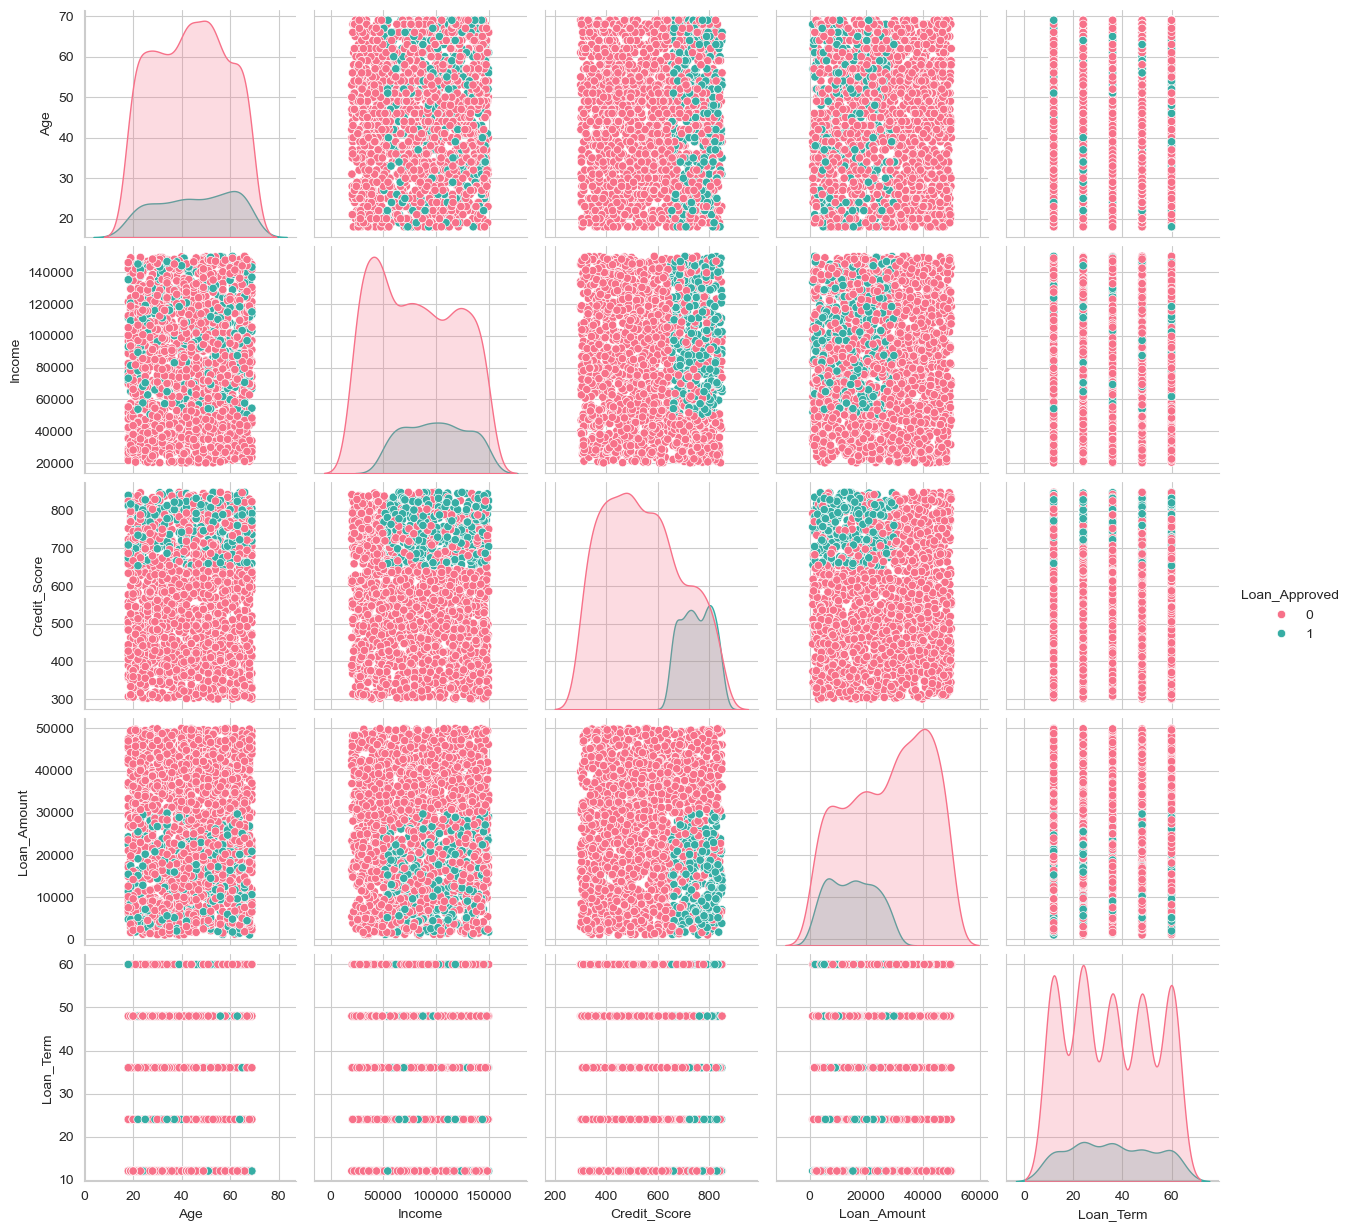

In [23]:
sns.pairplot(df, vars=num_features, hue="Loan_Approved", diag_kind="kde", palette="husl")
plt.show()

### 7. Detect Outliers

In [24]:
df.sample()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
1029,64,109881,700,15904,24,Employed,1


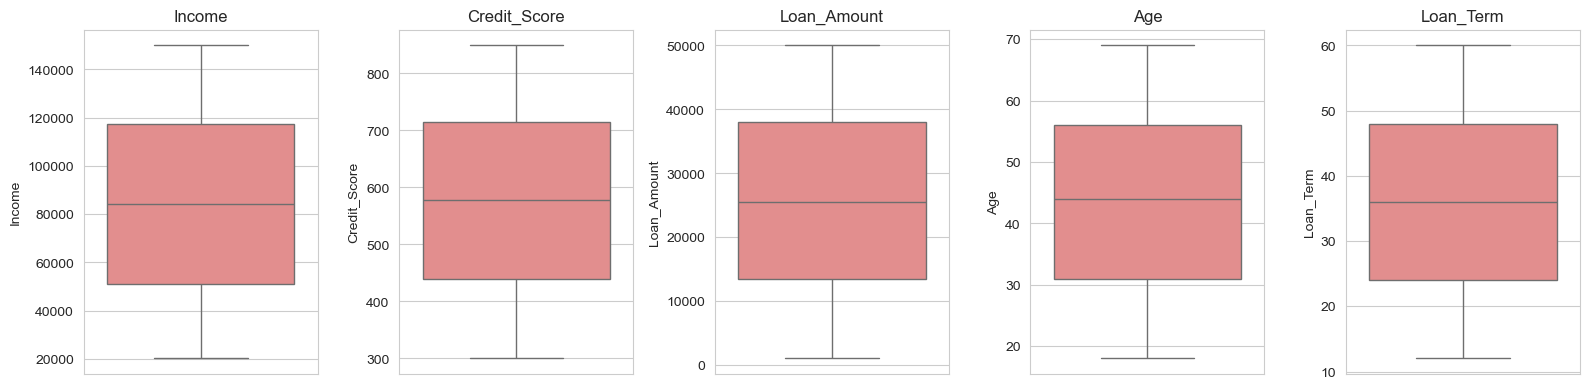

In [25]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
outlier_cols = ["Income","Credit_Score","Loan_Amount","Age","Loan_Term"]
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color="lightcoral")
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [26]:
def iqr_outlier_report(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (bounds: {lower:.1f} to {upper:.1f})")
    return outliers

for col in outlier_cols:
    iqr_outlier_report(df, col)

Income: 0 outliers (bounds: -48971.8 to 217420.2)
Credit_Score: 0 outliers (bounds: 27.1 to 1128.1)
Loan_Amount: 0 outliers (bounds: -23313.2 to 74706.8)
Age: 0 outliers (bounds: -6.5 to 93.5)
Loan_Term: 0 outliers (bounds: -12.0 to 84.0)


Note: Outliers here (e.g. very high income or low credit score) are plausible real-world values rather than data errors, so we keep them rather than dropping rows - removing them could discard genuine minority-class ("Approved") signal, especially since the target is already imbalanced (~17% approved).

### 8. Encode Categorical Features

In [27]:
le = LabelEncoder()
df["Employment_Status_Encoded"] = le.fit_transform(df["Employment_Status"])
le.classes_

array(['Employed', 'Self-Employed', 'Unemployed'], dtype=object)

In [28]:
le.transform(le.classes_)

array([0, 1, 2])

In [29]:
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Employed': np.int64(0), 'Self-Employed': np.int64(1), 'Unemployed': np.int64(2)}


In [30]:
df[["Employment_Status","Employment_Status_Encoded"]].drop_duplicates()

,Employment_Status,Employment_Status_Encoded
0,Employed,0
1,Self-Employed,1
3,Unemployed,2


### 9. Define Features & Target, then Scale Numerical Features

In [31]:
feature_cols = ["Age","Income","Credit_Score","Loan_Amount","Loan_Term","Employment_Status_Encoded"]
X = df[feature_cols].copy()
y = df["Loan_Approved"].copy()

X.head()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status_Encoded
0,56,81788,334,15022,48,0
1,69,102879,781,21013,24,1
2,46,58827,779,39687,60,1
3,32,127188,364,16886,24,2
4,60,25655,307,26256,36,2


In [32]:
y.head()

0    0
1    1
2    0
3    0
4    0
Name: Loan_Approved, dtype: int64

### 10. Train-Test Split (80/20, stratified)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:",X_test.shape)
print("Train target distribution:\n", y_train.value_counts(normalize=True))
print("Test target distribution:\n",y_test.value_counts(normalize=True))

Train shape: (1600, 6) Test shape: (400, 6)
Train target distribution:
 Loan_Approved
0    0.82875
1    0.17125
Name: proportion, dtype: float64
Test target distribution:
 Loan_Approved
0    0.83
1    0.17
Name: proportion, dtype: float64


In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]

array([[ 0.74303523,  0.39339108, -0.1173217 ,  0.16491058, -0.65925577,
        -0.7073077 ],
       [ 0.87728585, -0.70184171,  0.59019391,  0.38515879, -1.37148347,
        -0.7073077 ],
       [ 0.60878461,  1.15749456,  0.86427653,  1.121476  , -0.65925577,
        -0.7073077 ],
       [-1.67347594, -0.91620704, -0.31491616,  0.23308942, -0.65925577,
        -0.7073077 ],
       [ 0.27315806,  0.74224182, -0.79934126, -1.52121814,  0.05297194,
        -0.7073077 ]])

In [35]:
# Keep as DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)
X_train_scaled.head()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status_Encoded
1219,0.743035,0.393391,-0.117322,0.164911,-0.659256,-0.707308
1185,0.877286,-0.701842,0.590194,0.385159,-1.371483,-0.707308
1442,0.608785,1.157495,0.864277,1.121476,-0.659256,-0.707308
1531,-1.673476,-0.916207,-0.314916,0.233089,-0.659256,-0.707308
923,0.273158,0.742242,-0.799341,-1.521218,0.052972,-0.707308


Scaling is applied for Logistic Regression, KNN, SVM, and Naive Bayes. The Decision Tree is trained on the unscaled data since tree splits are scale-invariant, but for simplicity and a single consistent inference pipeline in the Streamlit app, we use the same scaled features for all five models (this does not hurt the Decision Tree's performance).

### 11. Train Five Classification Models

In [36]:
models = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
}
list(models.items())

[('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
 ('KNN', KNeighborsClassifier()),
 ('Naive Bayes', GaussianNB()),
 ('SVM', SVC(probability=True, random_state=42)),
 ('Decision Tree', DecisionTreeClassifier(random_state=42))]

In [37]:
trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"Trained:{name}")

Trained:Logistic Regression
Trained:KNN
Trained:Naive Bayes
Trained:SVM
Trained:Decision Tree


### 12. Evaluate Every Model

===== Logistic Regression =====
Accuracy : 0.9100
Precision: 0.7500
Recall   : 0.7059
F1-score : 0.7273
ROC-AUC  : 0.9659

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       332
           1       0.75      0.71      0.73        68

    accuracy                           0.91       400
   macro avg       0.85      0.83      0.84       400
weighted avg       0.91      0.91      0.91       400



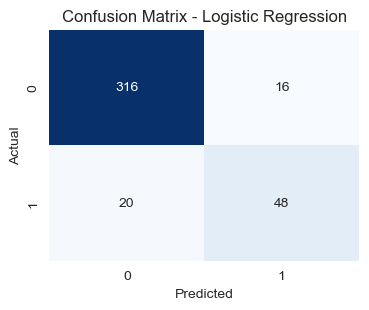

===== KNN =====
Accuracy : 0.9675
Precision: 0.9365
Recall   : 0.8676
F1-score : 0.9008
ROC-AUC  : 0.9844

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       332
           1       0.94      0.87      0.90        68

    accuracy                           0.97       400
   macro avg       0.95      0.93      0.94       400
weighted avg       0.97      0.97      0.97       400



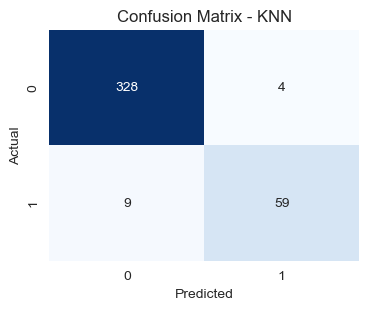

===== Naive Bayes =====
Accuracy : 0.9525
Precision: 0.9623
Recall   : 0.7500
F1-score : 0.8430
ROC-AUC  : 0.9928

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       332
           1       0.96      0.75      0.84        68

    accuracy                           0.95       400
   macro avg       0.96      0.87      0.91       400
weighted avg       0.95      0.95      0.95       400



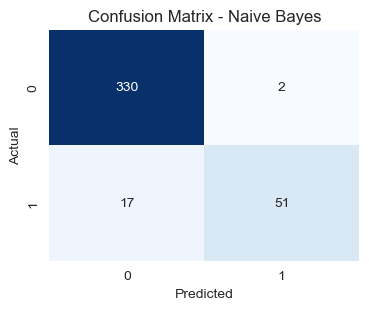

===== SVM =====
Accuracy : 0.9625
Precision: 0.9649
Recall   : 0.8088
F1-score : 0.8800
ROC-AUC  : 0.9921

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       332
           1       0.96      0.81      0.88        68

    accuracy                           0.96       400
   macro avg       0.96      0.90      0.93       400
weighted avg       0.96      0.96      0.96       400



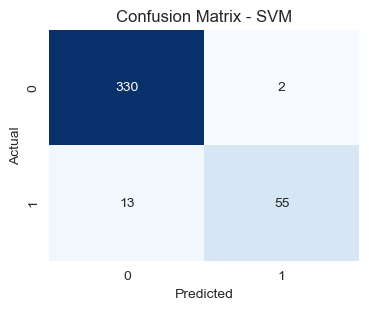

===== Decision Tree =====
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000
ROC-AUC  : 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       332
           1       1.00      1.00      1.00        68

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



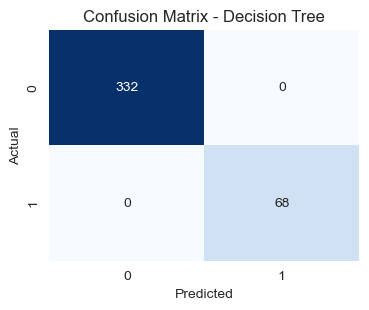

In [38]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    print(f"===== {name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1, "ROC-AUC": auc}, y_proba

results = []
roc_data = {}
for name, model in trained_models.items():
    res, y_proba = evaluate_model(name, model, X_test_scaled, y_test)
    results.append(res)
    if y_proba is not None:
        roc_data[name] = y_proba

### 13. Compare Models

In [39]:
results_df = pd.DataFrame(results).set_index("Model").sort_values("F1-score", ascending=False)
results_df.style.background_gradient(cmap="Greens")

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000
KNN,0.967500,0.936508,0.867647,0.900763,0.984364
SVM,0.962500,0.964912,0.808824,0.880000,0.992116
Naive Bayes,0.952500,0.962264,0.750000,0.842975,0.992780
Logistic Regression,0.910000,0.750000,0.705882,0.727273,0.965893


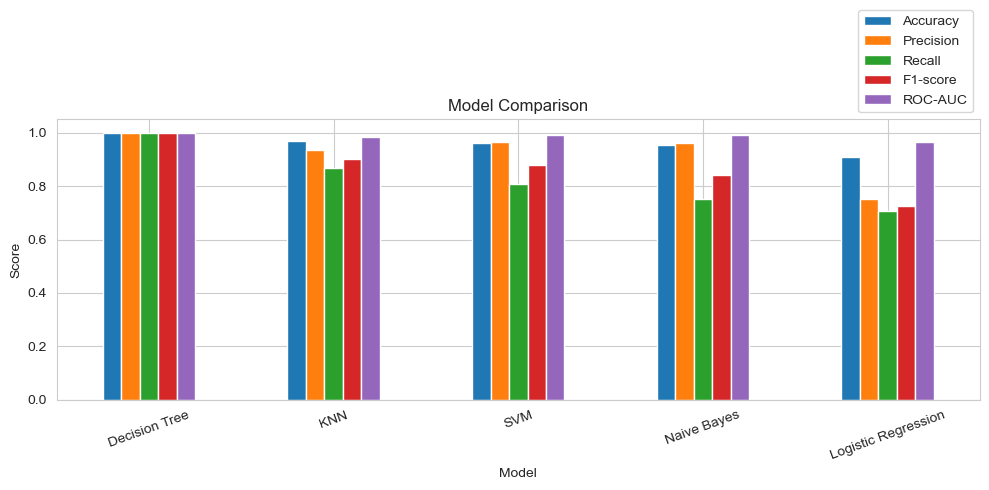

In [41]:
results_df[["Accuracy","Precision","Recall","F1-score","ROC-AUC"]].plot(
    kind="bar", figsize=(10,5)
)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(loc="lower right", bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()

In [42]:
best_baseline_name = results_df["F1-score"].idxmax()
print(f"Best baseline model (by F1-score): {best_baseline_name}")

Best baseline model (by F1-score): Decision Tree


### 14. Hyperparameter Tuning
Because the target is imbalanced, we tune using f1 as the scoring metric (rather than accuracy) with stratified 5-fold cross-validation.